# MNIST CNN Model Training, Evaluation, and Weight Export

## 0. Install Dependencies

Note: Python version 3.11.7 is used in this notebook.

In [ ]:
%pip install numpy tensorflow matplotlib scikit-learn

## 1. Import Required Libraries

In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import csv

from sklearn.model_selection import train_test_split

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

## 2. Load and Preprocess the MNIST Dataset
Load the MNIST dataset and preprocess it by normalizing the images and one-hot encoding the labels.

In [2]:
# Load and preprocess MNIST dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0  # Normalize the images to [0, 1]
x_train = np.expand_dims(x_train, -1)  # Add channel dimension
y_train = tf.keras.utils.to_categorical(y_train, 10)  # One-hot encode the labels

### 2.2 Prepare the test and train datasets

In [11]:
# Split the dataset into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

### 2.3 Save some images for later use in C/RiscV programs

In [12]:
# indices = random.sample(range(x_train.shape[0]), 5)

# with open("mnist_samples.txt", "w") as f:
#     for idx in indices:
#         image = x_train[idx].squeeze()  # (28, 28)
#         label = np.argmax(y_train[idx])

#         f.write(f"float image[28*28] = {{\n")
#         flat_values = image.flatten()
#         for i, val in enumerate(flat_values):
#             f.write(f"  {val:.6f}f,")
#             if (i + 1) % 28 == 0:
#                 f.write("\n")
#         f.write(f"}}; // Label: {label}\n\n")

In [13]:
indices = random.sample(range(x_train.shape[0]), 100)

with open("mnist_samples.csv", "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    
    for idx in indices:
        image = x_train[idx].squeeze()  # (28, 28)
        label = np.argmax(y_train[idx])  # Get label
        
        # Flatten the image and combine it with the label
        row = [label] + image.flatten().tolist()
        
        # Write row to CSV
        writer.writerow(row)


## 3. Visualize MNIST Images


### 3.1 Define a function to display images

In [14]:
def plot_mnist_images(x_data, num_images=25):
    """
    Function to plot a grid of random MNIST images from the dataset.
    
    Parameters:
    x_data (numpy array): The input images (28x28 grayscale).
    num_images (int): Number of images to display.
    """
    # Randomly select num_images indices from the dataset
    random_indices = np.random.choice(len(x_data), num_images, replace=False)

    # Get the corresponding images using the random indices
    random_images = x_data[random_indices]

    # Calculate the number of rows and columns needed to display the images
    cols = int(np.ceil(np.sqrt(num_images)))  # Number of columns based on the square root of num_images
    rows = int(np.ceil(num_images / cols))    # Number of rows based on the columns

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Loop through the axes and plot the images
    for i in range(num_images):
        axes[i].imshow(random_images[i], cmap='gray')
        axes[i].axis('off')

    # Hide any remaining unused subplots
    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.show()


### 3.2 Plot the first 25 MNIST images


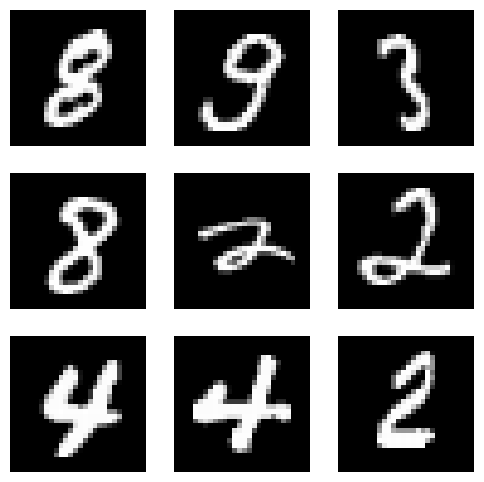

In [15]:
plot_mnist_images(x_train, num_images=9)

## 4. Build the Convolutional Neural Network (CNN)

Define the CNN model architecture:

- **Input layer:** 28x28 grayscale images

    $X \in \mathbb{R}^{28 \times 28 \times 1}$

- **Convolutional Layers:** 8 filters, 5x5 kernel, single stride, ReLU activation

    $Z \in \mathbb{R}^{24 \times 24 \times 8}$

- **Max Pooling layer:** 2x2 pooling, stride 2

    $A' \in \mathbb{R}^{12 \times 12 \times 8}$

- **Flatten:** 

    $A' \in \mathbb{R}^{12 \times 12 \times 8} \Rightarrow \mathbb{R}^{1152}$

- **Full Connected Layer:** 10 neurons

    $Z_{\text{fc}} = W_{\text{fc}} A' + b_{\text{fc}}$

    with, 
    - $W_{\text{fc}} \in \mathbb{R}^{10 \times 1152}$ is the weight matrix mapping 1152 features to 10 classes
    - $b_{\text{fc}} \in \mathbb{R}^{10}$ is the bias vector for the fully connected layer

- **Softmax Activation:**

   $\hat{y}_i = \frac{e^{Z_{\text{fc},i}}}{\sum_{j=1}^{10} e^{Z_{\text{fc},j}}}$


In [16]:
# Build the CNN model
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=8, kernel_size=(5, 5), strides=1, padding='valid', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Activation('softmax')
])

In [17]:
# Display the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        11,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,738 (45.85 KB)

 Trainable params: 11,738 (45.85 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile and Train the Model
Compile the model with the Adam optimizer and categorical cross-entropy loss function, then train the model on a subset of the data to initialize the weights.


In [18]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
# Train the model on a subset on the training data
history = model.fit(x_train, y_train, epochs=500, batch_size=32, verbose=1)

Epoch 1/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8189 - loss: 0.6273
Epoch 2/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9495 - loss: 0.1682
Epoch 3/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9638 - loss: 0.1221
Epoch 4/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9722 - loss: 0.0977
Epoch 5/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9760 - loss: 0.0808
Epoch 6/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9806 - loss: 0.0652
Epoch 7/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9834 - loss: 0.0534
Epoch 8/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9853 - loss: 0.0495
Epoch 9/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9859 - loss: 0.0438
Epoch 10/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9877 - loss: 0.0401
Epoch 11/500
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9894 - loss: 0.0353
Epoch 12/500
1050/1

## 6. Evaluate the Model
Evaluate the trained model on a validation or test set to assess its performance. The accuracy of the model is reported as a metric.

### 6.1 Plot the training history

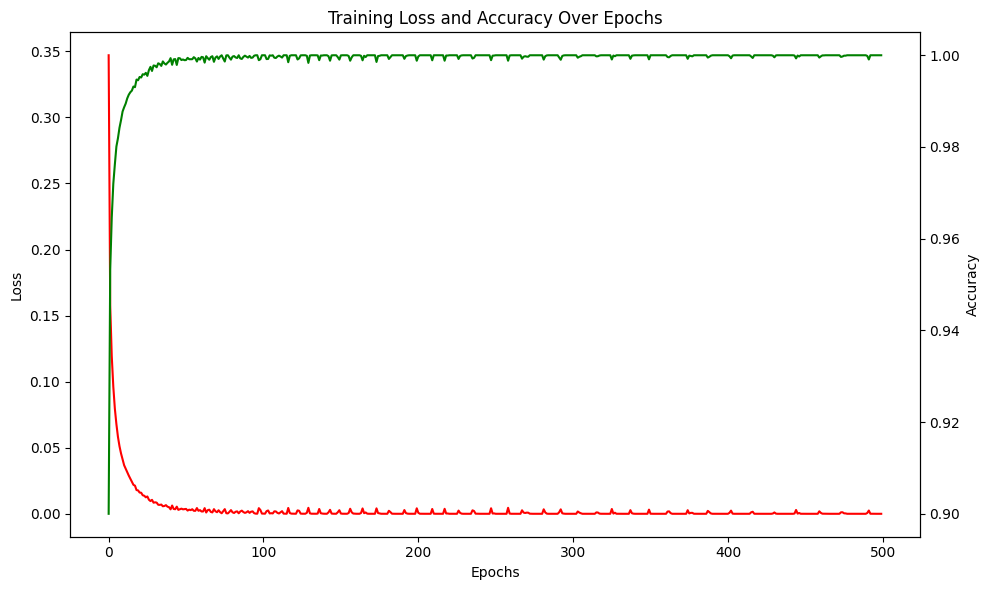

In [20]:
# Create a figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the training loss
ax1.plot(history.history['loss'], label='Training Loss', color='red')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss',)
ax1.tick_params(axis='y')

# Create a second y-axis for accuracy
ax2 = ax1.twinx()
ax2.plot(history.history['accuracy'], label='Training Accuracy', color='green')
ax2.set_ylabel('Accuracy')
ax2.tick_params(axis='y')

# Add title
plt.title('Training Loss and Accuracy Over Epochs')

# Display the plot
fig.tight_layout()
plt.show()


### 3.2 Evaluate the model on the test set

In [21]:
# Evaluate the model on the entire training set
test_loss, test_accuracy = model.evaluate(x_val, y_val, verbose=0)

print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9801


## 7. Save the Model Weights to a Text File
Extract the weights and biases from each layer of the trained model and save them in a clean, space-separated text file format.


In [22]:
# BAD FUNCTION: Messy heuristics, unclear formatting rules, magic numbers everywhere.
# But it works — so we're not touching it for now.
# TODO (maybe): Clean this up one day if readability or flexibility becomes a concern.

def write_array_plain(f, array, name):
    """Write a numpy array to a file in a comma-separated format (no trailing comma at line end)."""
    f.write(f"\n--- {name} ---\n")
    
    flat = array.flatten()
    length = len(flat)

    # Determine grouping based on array size
    if length > 300:
        nums_per_line = 1152
    elif length == 8:
        nums_per_line = 8
    elif length == 10:
        nums_per_line = 10
    else:
        nums_per_line = 5

    for i in range(0, length, nums_per_line):
        chunk = flat[i:i + nums_per_line]
        line = ", ".join(map(str, chunk))
        f.write(line + "\n")

        # Add extra newline after every 5 lines for convolution filters
        if nums_per_line == 5 and (i // nums_per_line + 1) % 5 == 0:
            f.write("\n")

In [23]:
# Write model weights to a file
filename = f"model_params.txt"

with open(filename, "w") as f:
    for i, layer in enumerate(model.layers):
        weights = layer.get_weights()
        f.write(f"\n==============================\n")
        f.write(f"Layer {i+1}: {layer.name.upper()}\n")
        f.write(f"==============================\n")
        if weights:
            write_array_plain(f, weights[0], "Weights")
            if len(weights) > 1:
                write_array_plain(f, weights[1], "Biases")
        else:
            f.write("(No trainable weights)\n")

In [24]:
model.save(f'mnist_cnn_model_{test_accuracy:.4f}.keras')
model.save(f'mnist_cnn_model.keras')